**Research Introduction**

This study applies reinforcement learning (RL) to the problem of optimal energy management in a residential electricity consumption setting. The objective is to develop intelligent control policies that minimize electricity cost by optimally scheduling battery charging and discharging under time-varying demand and pricing conditions.

Traditional energy management systems often rely on rule-based strategies, which are simple but limited in their ability to adapt to complex and dynamic environments. In contrast, reinforcement learning provides a data-driven framework in which an agent learns optimal decision-making through interaction with the environment. This makes RL particularly suitable for sequential decision problems involving uncertainty, delayed rewards, and trade-offs between short-term and long-term costs.

In this work, the energy management problem is formulated as a Markov Decision Process (MDP), where the state represents system conditions such as electricity demand, battery level, and temporal features; actions correspond to battery control decisions (charge, discharge, or idle); and the reward is defined as the negative total cost, incorporating both electricity cost and battery degradation penalties.

To provide a comprehensive analysis, multiple reinforcement learning algorithms are implemented and compared. These include Q-Learning, a value-based off-policy method; SARSA, an on-policy learning algorithm; and Deep Q-Network (DQN), which uses neural networks to approximate action-value functions in continuous state spaces. These approaches are benchmarked against a rule-based baseline policy that leverages time-of-use pricing for decision-making.

The study introduces a structured experimental framework that includes feature engineering of temporal demand patterns, discretized and continuous state representations, training across multiple episodes, and evaluation over multiple test windows. Performance is assessed using metrics such as total operational cost, convergence behavior, and policy stability.

The goal of this research is not only to identify the most cost-efficient algorithm but also to analyze the strengths and limitations of classical and deep reinforcement learning methods in real-world energy optimization scenarios. This work ultimately evaluates whether data-driven learning approaches can outperform traditional heuristic strategies in structured environments.


In [64]:
# DEEP REGENERATED RL CODE FOR ENERGY MANAGEMENT
# Compares Rule-Based, Q-Learning, SARSA, and DQN

%matplotlib inline

import zipfile
import random
from dataclasses import dataclass
from collections import defaultdict, deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.optim as optim

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [65]:
# 1. REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [66]:
# 2. DATA LOADING AND PREPROCESSING
ZIP_PATH = "/content/archive.zip"
TXT_NAME = "household_power_consumption.txt"


def load_power_data(zip_path: str, txt_name: str) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path, "r") as z:
        with z.open(txt_name) as f:
            df = pd.read_csv(f, sep=";", na_values="?", low_memory=False)
    return df


def preprocess_power_data(df: pd.DataFrame) -> pd.DataFrame:
    df["datetime"] = pd.to_datetime(
        df["Date"] + " " + df["Time"],
        format="%d/%m/%Y %H:%M:%S",
        errors="coerce"
    )

    numeric_cols = [
        "Global_active_power",
        "Global_reactive_power",
        "Voltage",
        "Global_intensity",
        "Sub_metering_1",
        "Sub_metering_2",
        "Sub_metering_3"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["datetime", "Global_active_power"]).copy()
    df = df.sort_values("datetime")

    hourly = (
        df.set_index("datetime")[["Global_active_power"]]
        .resample("1h")
        .mean()
        .dropna()
        .rename(columns={"Global_active_power": "demand_kw"})
    )

    hourly["hour"] = hourly.index.hour
    hourly["dayofweek"] = hourly.index.dayofweek
    hourly["month"] = hourly.index.month
    hourly["is_weekend"] = hourly["dayofweek"].isin([5, 6]).astype(int)

    hourly["hour_sin"] = np.sin(2 * np.pi * hourly["hour"] / 24)
    hourly["hour_cos"] = np.cos(2 * np.pi * hourly["hour"] / 24)
    hourly["dow_sin"] = np.sin(2 * np.pi * hourly["dayofweek"] / 7)
    hourly["dow_cos"] = np.cos(2 * np.pi * hourly["dayofweek"] / 7)
    hourly["month_sin"] = np.sin(2 * np.pi * hourly["month"] / 12)
    hourly["month_cos"] = np.cos(2 * np.pi * hourly["month"] / 12)

    hourly["lag_1"] = hourly["demand_kw"].shift(1)
    hourly["lag_24"] = hourly["demand_kw"].shift(24)
    hourly["rolling_mean_24"] = hourly["demand_kw"].rolling(24).mean()
    hourly["rolling_std_24"] = hourly["demand_kw"].rolling(24).std()

    hourly = hourly.dropna().copy()
    return hourly


def time_of_use_price(hour: int) -> float:
    if 0 <= hour < 6:
        return 0.10
    elif 6 <= hour < 17:
        return 0.18
    elif 17 <= hour < 22:
        return 0.30
    else:
        return 0.15


def add_prices(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["price"] = df["hour"].apply(time_of_use_price)
    return df


def split_dataset(df: pd.DataFrame, train_ratio=0.7, val_ratio=0.15):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df


raw_df = load_power_data(ZIP_PATH, TXT_NAME)
hourly_df = preprocess_power_data(raw_df)
hourly_df = add_prices(hourly_df)

train_df, val_df, test_df = split_dataset(hourly_df)

print("Full shape:", hourly_df.shape)
print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)
display(hourly_df.head())

Full shape: (34144, 16)
Train: (23900, 16) Val: (5122, 16) Test: (5122, 16)


,demand_kw,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_24,rolling_mean_24,rolling_std_24,price
datetime,,,,,,,,,,,,,,,,
2006-12-17 17:00:00,3.406767,17,6,12,1,-0.965926,-2.588190e-01,-0.781831,0.62349,-2.449294e-16,1.0,3.326033,4.222889,2.465140,0.752521,0.3
2006-12-17 18:00:00,3.697100,18,6,12,1,-1.000000,-1.836970e-16,-0.781831,0.62349,-2.449294e-16,1.0,3.406767,3.632200,2.467844,0.757001,0.3
2006-12-17 19:00:00,2.908400,19,6,12,1,-0.965926,2.588190e-01,-0.781831,0.62349,-2.449294e-16,1.0,3.697100,3.400233,2.447351,0.737057,0.3
2006-12-17 20:00:00,3.361500,20,6,12,1,-0.866025,5.000000e-01,-0.781831,0.62349,-2.449294e-16,1.0,2.908400,3.268567,2.451224,0.741788,0.3
2006-12-17 21:00:00,3.040767,21,6,12,1,-0.707107,7.071068e-01,-0.781831,0.62349,-2.449294e-16,1.0,3.361500,3.056467,2.450569,0.741237,0.3


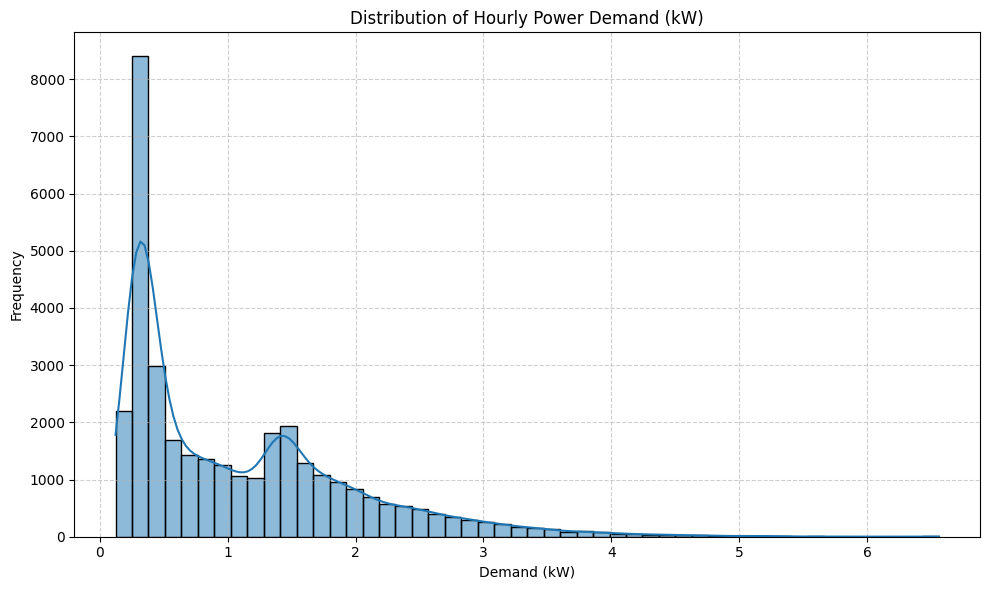

In [88]:
#Exploratory Data Analysis

import matplotlib.pyplot as plt
import seaborn as sns

# i. Demand Distribution
plt.figure(figsize=(10, 6))
sns.histplot(hourly_df['demand_kw'], bins=50, kde=True)
plt.title('Distribution of Hourly Power Demand (kW)')
plt.xlabel('Demand (kW)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

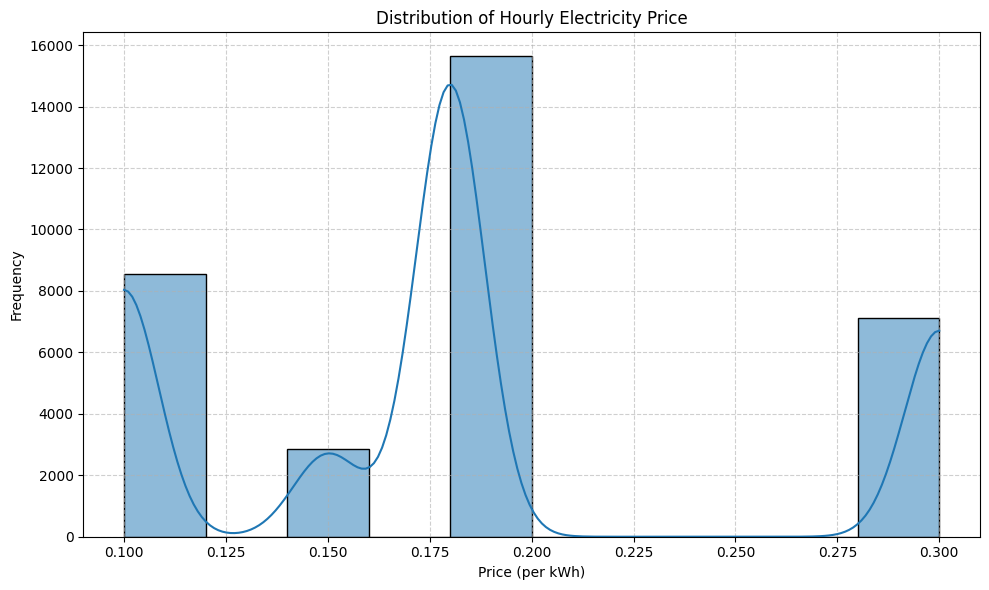

In [89]:
# ii. Price Distribution
plt.figure(figsize=(10, 6))
sns.histplot(hourly_df['price'], bins=10, kde=True)
plt.title('Distribution of Hourly Electricity Price')
plt.xlabel('Price (per kWh)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

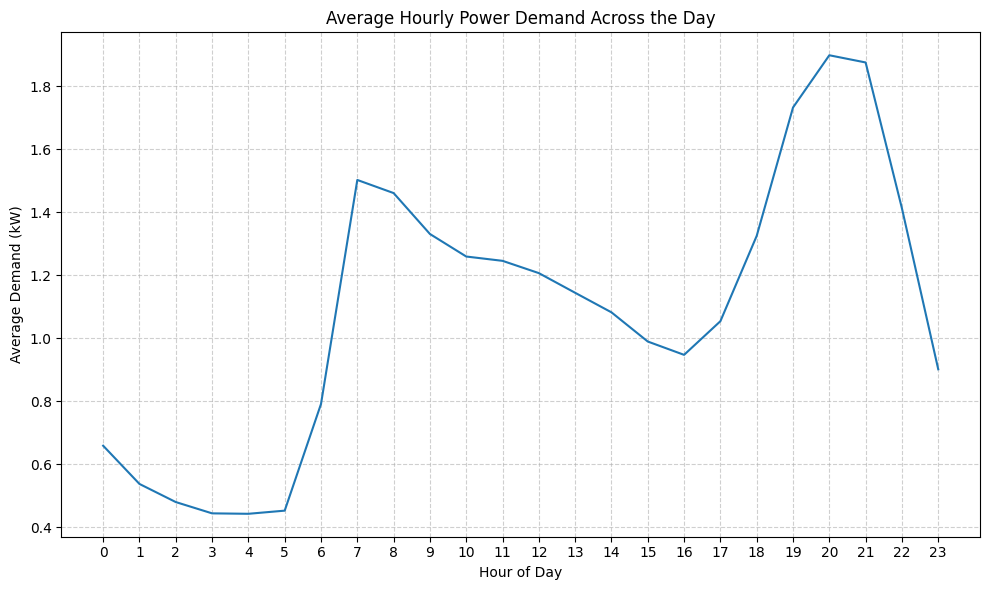

In [90]:
# iii. Average Daily Demand Pattern
daily_demand_pattern = hourly_df.groupby('hour')['demand_kw'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='hour', y='demand_kw', data=daily_demand_pattern)
plt.title('Average Hourly Power Demand Across the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Demand (kW)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

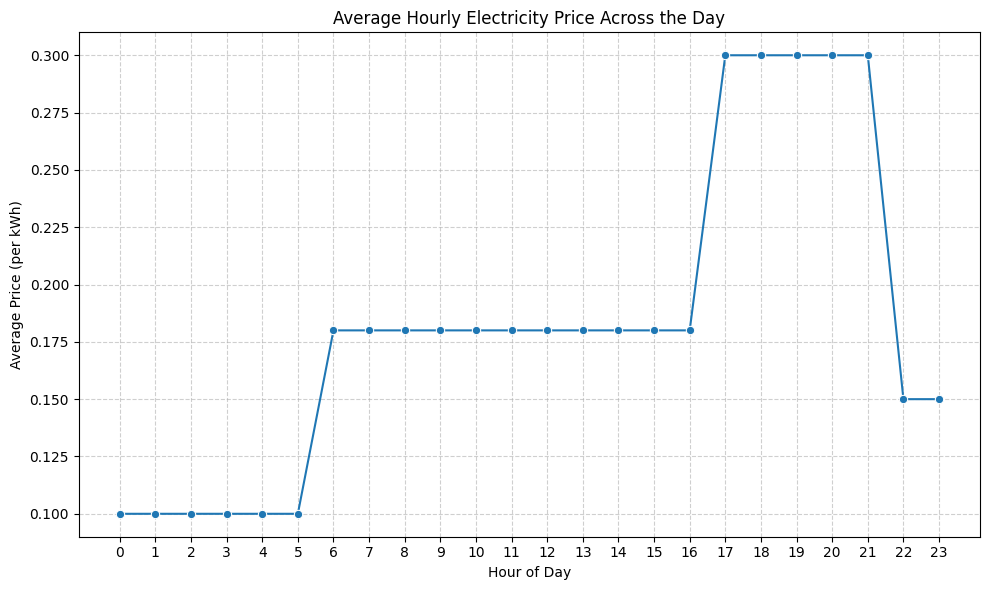

In [91]:
# iv. Average Daily Price Pattern
daily_price_pattern = hourly_df.groupby('hour')['price'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='hour', y='price', data=daily_price_pattern, marker='o')
plt.title('Average Hourly Electricity Price Across the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Price (per kWh)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

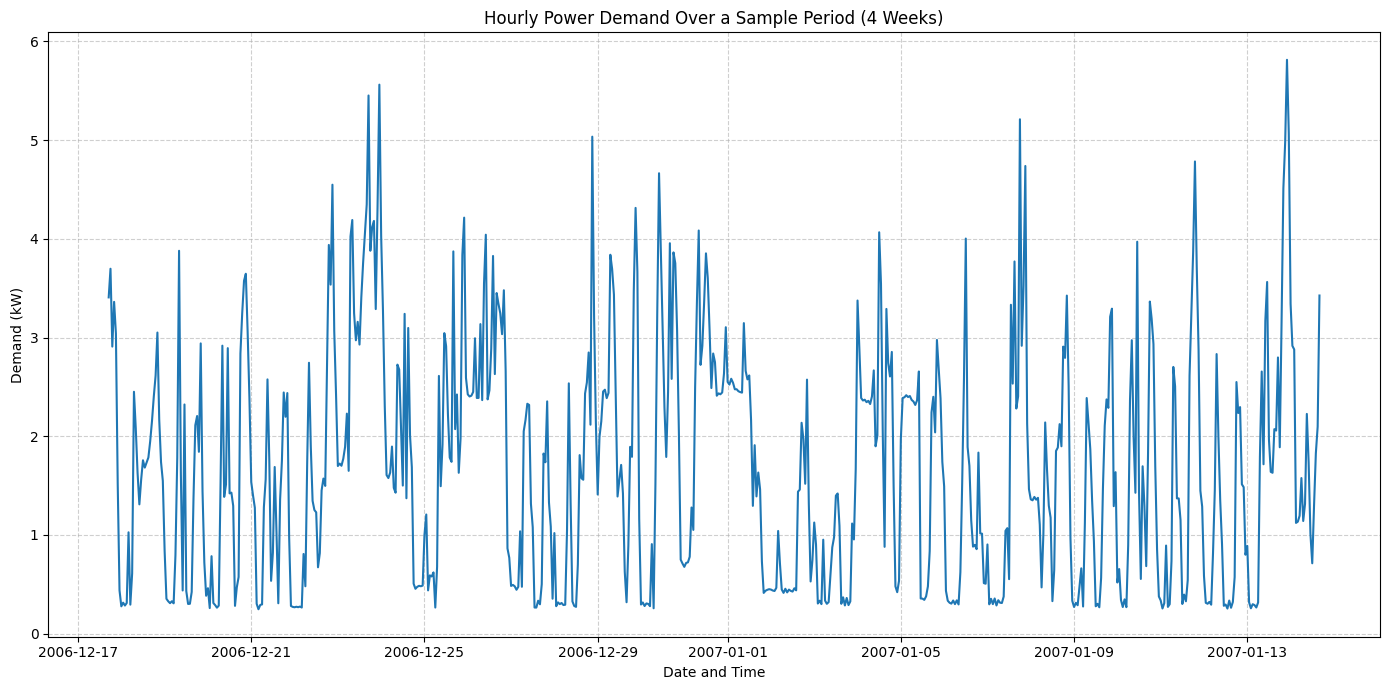

In [92]:
# v. Demand Over Time (Sample for readability)
plt.figure(figsize=(14, 7))
sns.lineplot(x=hourly_df.index[:24*7*4], y=hourly_df['demand_kw'].head(24*7*4))
plt.title('Hourly Power Demand Over a Sample Period (4 Weeks)')
plt.xlabel('Date and Time')
plt.ylabel('Demand (kW)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

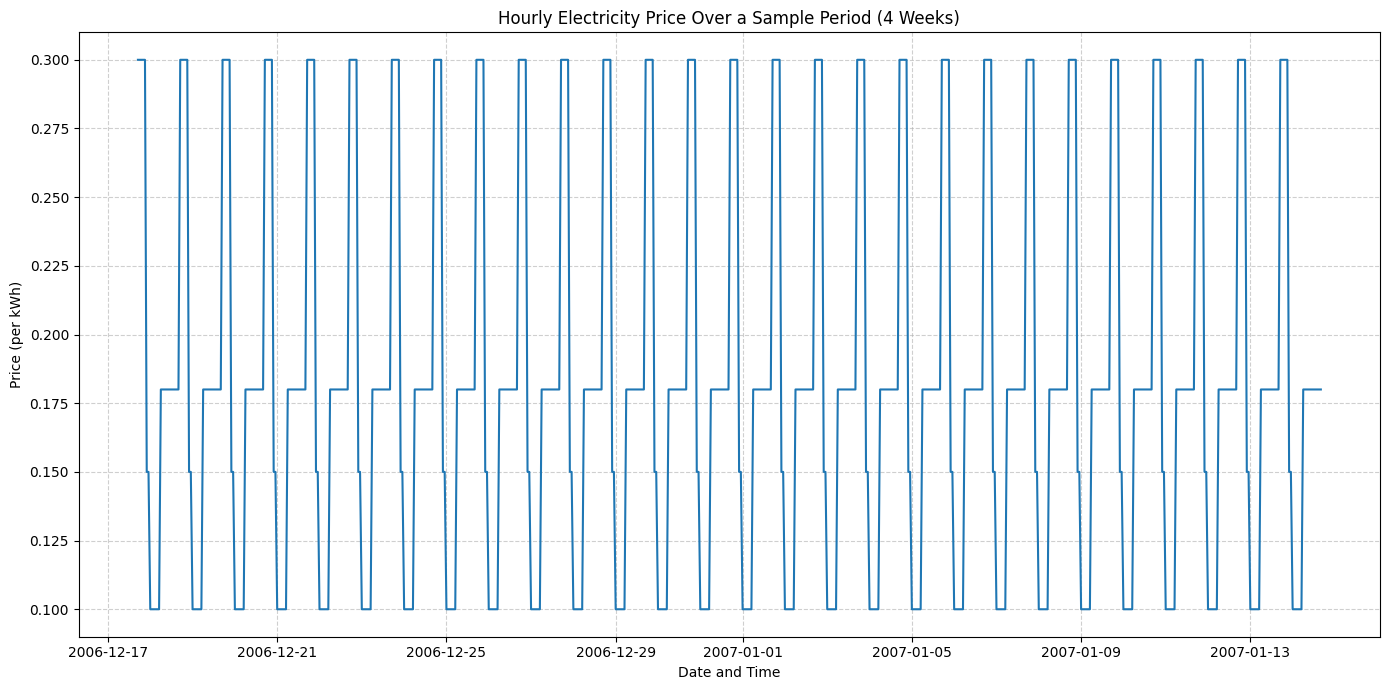

In [93]:
# vi. Price Over Time (Sample for readability)
plt.figure(figsize=(14, 7))
sns.lineplot(x=hourly_df.index[:24*7*4], y=hourly_df['price'].head(24*7*4))
plt.title('Hourly Electricity Price Over a Sample Period (4 Weeks)')
plt.xlabel('Date and Time')
plt.ylabel('Price (per kWh)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

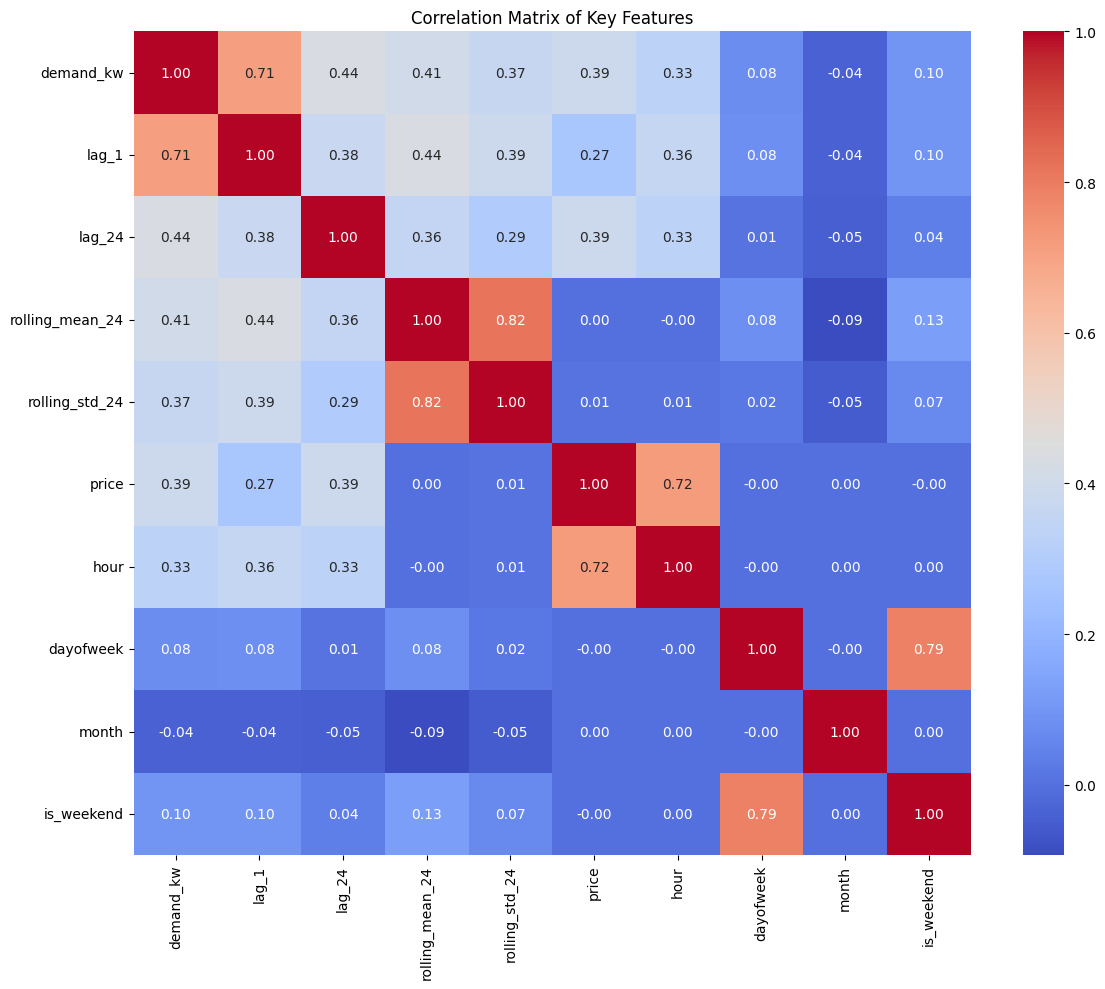

In [94]:
# vii. Correlation Matrix of Features

# Exclude non-numeric columns and cyclical features if they are redundant for correlation matrix
# Keep the base hour, dayofweek, month for initial correlation
eda_features = [
    'demand_kw', 'lag_1', 'lag_24', 'rolling_mean_24', 'rolling_std_24',
    'price', 'hour', 'dayofweek', 'month', 'is_weekend'
]

# Ensure all features exist before trying to plot
existing_features = [f for f in eda_features if f in hourly_df.columns]

plt.figure(figsize=(12, 10))
sns.heatmap(hourly_df[existing_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Key Features')
plt.tight_layout()
plt.show()

In [67]:
# 3. BATTERY CONFIGURATION

@dataclass
class BatteryConfig:
    capacity_kwh: float = 10.0
    max_charge_kw: float = 2.5
    max_discharge_kw: float = 2.5
    efficiency: float = 0.95
    degradation_penalty: float = 0.01
    unmet_demand_penalty: float = 0.0
    export_allowed: bool = False

In [68]:
# 4. ENVIRONMENT
@dataclass
class BatteryConfig:
    capacity_kwh: float = 10.0
    max_charge_kw: float = 2.5
    max_discharge_kw: float = 2.5
    efficiency: float = 0.95
    degradation_penalty: float = 0.01


class EnergyEnv:
    """
    Actions:
    0 = idle
    1 = charge
    2 = discharge
    """

    def __init__(self, demand_df: pd.DataFrame, config: BatteryConfig):
        self.df = demand_df.reset_index(drop=False).copy()
        self.config = config
        self.ptr = 0
        self.battery_kwh = config.capacity_kwh / 2

    def reset(self, start_idx: int = 0):
        self.ptr = start_idx
        self.battery_kwh = self.config.capacity_kwh / 2
        return self._get_state()

    def _get_state(self):
        row = self.df.iloc[self.ptr]
        return {
            "hour": int(row["hour"]),
            "dayofweek": int(row["dayofweek"]),
            "month": int(row["month"]),
            "is_weekend": int(row["is_weekend"]),
            "demand_kw": float(row["demand_kw"]),
            "lag_1": float(row["lag_1"]),
            "lag_24": float(row["lag_24"]),
            "rolling_mean_24": float(row["rolling_mean_24"]),
            "rolling_std_24": float(row["rolling_std_24"]),
            "price": float(row["price"]),
            "battery_kwh": float(self.battery_kwh),
            "hour_sin": float(row["hour_sin"]),
            "hour_cos": float(row["hour_cos"]),
            "dow_sin": float(row["dow_sin"]),
            "dow_cos": float(row["dow_cos"]),
            "month_sin": float(row["month_sin"]),
            "month_cos": float(row["month_cos"]),
        }

    def step(self, action: int):
        row = self.df.iloc[self.ptr]
        demand_kw = float(row["demand_kw"])
        price = float(row["price"])

        battery_before = self.battery_kwh
        grid_usage_kwh = demand_kw
        charge_amount = 0.0
        discharge_amount = 0.0

        if action == 1:
            charge_amount = min(
                self.config.max_charge_kw,
                self.config.capacity_kwh - self.battery_kwh
            )
            self.battery_kwh += charge_amount * self.config.efficiency
            grid_usage_kwh = demand_kw + charge_amount

        elif action == 2:
            available_discharge = min(self.config.max_discharge_kw, self.battery_kwh)
            discharge_amount = min(available_discharge, demand_kw)
            self.battery_kwh -= discharge_amount
            grid_usage_kwh = max(0.0, demand_kw - discharge_amount)

        self.battery_kwh = float(np.clip(self.battery_kwh, 0.0, self.config.capacity_kwh))

        energy_cost = grid_usage_kwh * price
        degradation_cost = abs(self.battery_kwh - battery_before) * self.config.degradation_penalty
        total_cost = energy_cost + degradation_cost
        reward = -total_cost

        self.ptr += 1
        done = self.ptr >= len(self.df) - 1
        next_state = None if done else self._get_state()

        info = {
            "total_cost": total_cost,
            "energy_cost": energy_cost,
            "degradation_cost": degradation_cost,
            "price": price,
            "demand_kw": demand_kw,
            "battery_kwh": self.battery_kwh,
            "grid_usage_kwh": grid_usage_kwh,
            "action": action
        }
        return next_state, reward, done, info

In [69]:
# 5. RULE-BASED POLICY
def rule_based_policy(state: dict) -> int:
    hour = state["hour"]
    price = state["price"]
    battery = state["battery_kwh"]

    if 0 <= hour < 6 and battery < 8.5:
        return 1
    if 17 <= hour < 22 and battery > 1.0:
        return 2
    if price >= 0.30 and battery > 2.0:
        return 2
    return 0

In [70]:
# 6. TABULAR STATE DISCRETIZER
class StateDiscretizer:
    def __init__(self, max_demand, capacity_kwh, demand_bins=15, battery_bins=12):
        self.max_demand = max_demand
        self.capacity_kwh = capacity_kwh
        self.demand_bins = demand_bins
        self.battery_bins = battery_bins
        self.price_levels = [0.10, 0.15, 0.18, 0.30]

    def demand_bin(self, demand_kw):
        scaled = demand_kw / max(self.max_demand, 1e-6)
        return min(self.demand_bins - 1, max(0, int(scaled * self.demand_bins)))

    def battery_bin(self, battery_kwh):
        scaled = battery_kwh / max(self.capacity_kwh, 1e-6)
        return min(self.battery_bins - 1, max(0, int(scaled * self.battery_bins)))

    def price_bin(self, price):
        if price in self.price_levels:
            return self.price_levels.index(price)
        return 0

    def transform(self, state):
        return (
            int(state["hour"]),
            int(state["dayofweek"]),
            self.demand_bin(state["demand_kw"]),
            self.battery_bin(state["battery_kwh"]),
            self.price_bin(state["price"]),
        )

In [71]:
# 7. TABULAR Q-LEARNING AGENT
class QLearningAgent:
    def __init__(
        self,
        actions=3,
        alpha=0.1,
        gamma=0.98,
        epsilon=1.0,
        epsilon_decay=0.995,
        epsilon_min=0.05
    ):
        self.actions = actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.q_table = defaultdict(lambda: np.zeros(self.actions, dtype=np.float32))

    def choose_action(self, state, greedy=False):
        if (not greedy) and (random.random() < self.epsilon):
            return random.randint(0, self.actions - 1)
        return int(np.argmax(self.q_table[state]))

    def learn(self, state, action, reward, next_state, done):
        q_current = self.q_table[state][action]
        if done or next_state is None:
            q_target = reward
        else:
            q_target = reward + self.gamma * np.max(self.q_table[next_state])
        self.q_table[state][action] += self.alpha * (q_target - q_current)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)



In [72]:
# 8. TABULAR SARSA AGENT
class SARSAAgent:
    def __init__(
        self,
        actions=3,
        alpha=0.1,
        gamma=0.98,
        epsilon=1.0,
        epsilon_decay=0.995,
        epsilon_min=0.05
    ):
        self.actions = actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.q_table = defaultdict(lambda: np.zeros(self.actions, dtype=np.float32))

    def choose_action(self, state, greedy=False):
        if (not greedy) and (random.random() < self.epsilon):
            return random.randint(0, self.actions - 1)
        return int(np.argmax(self.q_table[state]))

    def learn(self, state, action, reward, next_state, next_action, done):
        q_current = self.q_table[state][action]
        if done or next_state is None:
            q_target = reward
        else:
            q_target = reward + self.gamma * self.q_table[next_state][next_action]
        self.q_table[state][action] += self.alpha * (q_target - q_current)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)



In [73]:
#Continuous Learning
STATE_FEATURES = [
    "demand_kw",
    "lag_1",
    "lag_24",
    "rolling_mean_24",
    "rolling_std_24",
    "price",
    "battery_kwh",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]


class ContinuousStateBuilder:
    def __init__(self):
        self.scaler = MinMaxScaler()

    def fit(self, df: pd.DataFrame, battery_capacity: float):
        temp = df.copy()
        temp["battery_kwh"] = battery_capacity / 2
        X = temp[STATE_FEATURES].values
        self.scaler.fit(X)

    def transform(self, state: dict):
        vec = np.array([[state[f] for f in STATE_FEATURES]], dtype=np.float32)
        return self.scaler.transform(vec).flatten()

In [74]:
# 9. DQN and DOUBLE DQN COMPONENTS


class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = zip(*batch)
        return (
            np.array(s, dtype=np.float32),
            np.array(a, dtype=np.int64),
            np.array(r, dtype=np.float32),
            np.array(ns, dtype=np.float32),
            np.array(d, dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)


class QNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.net(x)


class DQNAgent:
    def __init__(
        self,
        state_dim,
        action_dim=3,
        lr=1e-3,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.995,
        epsilon_min=0.05,
        batch_size=64,
        buffer_capacity=50000,
        target_update_freq=250,
        double_dqn=False
    ):
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.double_dqn = double_dqn
        self.learn_step = 0

        self.policy_net = QNet(state_dim, action_dim).to(DEVICE)
        self.target_net = QNet(state_dim, action_dim).to(DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()
        self.memory = ReplayBuffer(buffer_capacity)

    def choose_action(self, state_vec, greedy=False):
        if (not greedy) and (random.random() < self.epsilon):
            return random.randint(0, self.action_dim - 1)

        x = torch.tensor(state_vec, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            qvals = self.policy_net(x)
        return int(torch.argmax(qvals, dim=1).item())

    def store(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)

    def learn(self):
        if len(self.memory) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

        states = torch.tensor(states, dtype=torch.float32, device=DEVICE)
        actions = torch.tensor(actions, dtype=torch.long, device=DEVICE).unsqueeze(1)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=DEVICE).unsqueeze(1)
        next_states = torch.tensor(next_states, dtype=torch.float32, device=DEVICE)
        dones = torch.tensor(dones, dtype=torch.float32, device=DEVICE).unsqueeze(1)

        current_q = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            if self.double_dqn:
                next_actions = self.policy_net(next_states).argmax(dim=1, keepdim=True)
                next_q = self.target_net(next_states).gather(1, next_actions)
            else:
                next_q = self.target_net(next_states).max(dim=1, keepdim=True)[0]

            target_q = rewards + (1 - dones) * self.gamma * next_q

        loss = self.loss_fn(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.learn_step += 1
        if self.learn_step % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return float(loss.item())

    def decay(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


In [75]:
# 10. STATE VECTOR FOR DQN
STATE_FEATURES = [
    "demand_kw",
    "lag_1",
    "lag_24",
    "rolling_mean_24",
    "rolling_std_24",
    "price",
    "battery_kwh",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]


class ContinuousStateBuilder:
    def __init__(self, scaler: MinMaxScaler = None):
        self.scaler = scaler

    def fit_scaler(self, df: pd.DataFrame, battery_capacity: float):
        temp = df.copy()
        temp["battery_kwh"] = battery_capacity / 2
        X = temp[STATE_FEATURES].values
        self.scaler = MinMaxScaler()
        self.scaler.fit(X)

    def transform(self, state: dict) -> np.ndarray:
        vec = np.array([[state[f] for f in STATE_FEATURES]], dtype=np.float32)
        vec_scaled = self.scaler.transform(vec)
        return vec_scaled.flatten()


In [76]:
import random
from collections import defaultdict, deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.optim as optim

# 11. TRAINING FUNCTIONS
def train_q_learning(env, agent, discretizer, episodes=150, episode_length=24*7):
    rewards_history, cost_history = [], []
    max_start = len(env.df) - episode_length - 1

    for ep in range(episodes):
        state = env.reset(start_idx=random.randint(0, max_start))
        s = discretizer.transform(state)
        total_reward, total_cost = 0.0, 0.0

        for _ in range(episode_length):
            action = agent.choose_action(s)
            next_state, reward, done, info = env.step(action)
            next_s = None if next_state is None else discretizer.transform(next_state)

            agent.learn(s, action, reward, next_s, done)

            total_reward += reward
            total_cost += info["total_cost"]

            if done:
                break
            s = next_s

        agent.decay_epsilon()
        rewards_history.append(total_reward)
        cost_history.append(total_cost)

    return rewards_history, cost_history


def train_sarsa(env, agent, discretizer, episodes=150, episode_length=24*7):
    rewards_history, cost_history = [], []
    max_start = len(env.df) - episode_length - 1

    for ep in range(episodes):
        state = env.reset(start_idx=random.randint(0, max_start))
        s = discretizer.transform(state)
        action = agent.choose_action(s)
        total_reward, total_cost = 0.0, 0.0

        for _ in range(episode_length):
            next_state, reward, done, info = env.step(action)
            total_reward += reward
            total_cost += info["total_cost"]

            if done or next_state is None:
                agent.learn(s, action, reward, None, None, True)
                break

            next_s = discretizer.transform(next_state)
            next_action = agent.choose_action(next_s)
            agent.learn(s, action, reward, next_s, next_action, False)

            s = next_s
            action = next_action

        agent.decay_epsilon()
        rewards_history.append(total_reward)
        cost_history.append(total_cost)

    return rewards_history, cost_history


def train_dqn(env, agent, state_builder, episodes=150, episode_length=24*7):
    rewards_history, cost_history, loss_history = [], [], []
    max_start = len(env.df) - episode_length - 1

    for ep in range(episodes):
        state = env.reset(start_idx=random.randint(0, max_start))
        s = state_builder.transform(state)

        total_reward, total_cost = 0.0, 0.0
        losses = []

        for _ in range(episode_length):
            action = agent.choose_action(s)
            next_state, reward, done, info = env.step(action)

            next_s = np.zeros_like(s) if next_state is None else state_builder.transform(next_state)
            agent.store(s, action, reward, next_s, done)

            loss = agent.learn()
            if loss is not None:
                losses.append(loss)

            total_reward += reward
            total_cost += info["total_cost"]

            if done:
                break
            s = next_s

        agent.decay()
        rewards_history.append(total_reward)
        cost_history.append(total_cost)
        loss_history.append(np.mean(losses) if len(losses) else np.nan)

    return rewards_history, cost_history, loss_history

In [77]:
# 12. EVALUATION FUNCTIONS
def evaluate_rule_based(env, start_idx=0, steps=24*7):
    state = env.reset(start_idx=start_idx)
    total_cost, total_reward = 0.0, 0.0
    traces = {"battery": [], "price": [], "demand": [], "action": [], "cost": []}

    for _ in range(steps):
        action = rule_based_policy(state)
        next_state, reward, done, info = env.step(action)

        total_cost += info["total_cost"]
        total_reward += reward

        traces["battery"].append(info["battery_kwh"])
        traces["price"].append(info["price"])
        traces["demand"].append(info["demand_kw"])
        traces["action"].append(action)
        traces["cost"].append(info["total_cost"])

        if done:
            break
        state = next_state

    return {"total_cost": total_cost, "total_reward": total_reward, **traces}


def evaluate_tabular(env, agent, discretizer, start_idx=0, steps=24*7):
    state = env.reset(start_idx=start_idx)
    total_cost, total_reward = 0.0, 0.0
    traces = {"battery": [], "price": [], "demand": [], "action": [], "cost": []}

    for _ in range(steps):
        s = discretizer.transform(state)
        action = agent.choose_action(s, greedy=True)
        next_state, reward, done, info = env.step(action)

        total_cost += info["total_cost"]
        total_reward += reward

        traces["battery"].append(info["battery_kwh"])
        traces["price"].append(info["price"])
        traces["demand"].append(info["demand_kw"])
        traces["action"].append(action)
        traces["cost"].append(info["total_cost"])

        if done:
            break
        state = next_state

    return {"total_cost": total_cost, "total_reward": total_reward, **traces}


def evaluate_dqn(env, agent, state_builder, start_idx=0, steps=24*7):
    state = env.reset(start_idx=start_idx)
    total_cost, total_reward = 0.0, 0.0
    traces = {"battery": [], "price": [], "demand": [], "action": [], "cost": []}

    for _ in range(steps):
        s = state_builder.transform(state)
        action = agent.choose_action(s, greedy=True)
        next_state, reward, done, info = env.step(action)

        total_cost += info["total_cost"]
        total_reward += reward

        traces["battery"].append(info["battery_kwh"])
        traces["price"].append(info["price"])
        traces["demand"].append(info["demand_kw"])
        traces["action"].append(action)
        traces["cost"].append(info["total_cost"])

        if done:
            break
        state = next_state

    return {"total_cost": total_cost, "total_reward": total_reward, **traces}


In [78]:
# 13. PLOTTING HELPERS
def moving_average(x, window=10):
    x = np.array(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")


def plot_training(values, title, ylabel):
    plt.figure(figsize=(10, 4))
    plt.plot(values, alpha=0.4, label="Raw")
    ma = moving_average(values, 10)
    if len(ma) > 0:
        offset = len(values) - len(ma)
        plt.plot(np.arange(offset, offset + len(ma)), ma, linewidth=2, label="Moving Avg")
    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_cost_bar(costs):
    plt.figure(figsize=(8, 5))
    plt.bar(list(costs.keys()), list(costs.values()))
    plt.title("Cost Comparison Across Algorithms")
    plt.ylabel("Total Cost")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


def plot_trace(result, name):
    plt.figure(figsize=(12, 4))
    plt.plot(result["battery"])
    plt.title(f"{name} Battery Level")
    plt.xlabel("Time Step")
    plt.ylabel("Battery (kWh)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [79]:
config = BatteryConfig()
train_env = EnergyEnv(train_df, config)
test_env = EnergyEnv(test_df, config)

discretizer = StateDiscretizer(
    max_demand=float(train_df["demand_kw"].max()),
    capacity_kwh=config.capacity_kwh
)

state_builder = ContinuousStateBuilder()
state_builder.fit_scaler(train_df, config.capacity_kwh)

q_agent = QLearningAgent()
sarsa_agent = SARSAAgent()
dqn_agent = DQNAgent(state_dim=len(STATE_FEATURES), double_dqn=False)
ddqn_agent = DQNAgent(state_dim=len(STATE_FEATURES), double_dqn=True)

EPISODES = 120
EPISODE_LENGTH = 24 * 7

print("Training Q-Learning...")
q_rewards, q_costs = train_q_learning(train_env, q_agent, discretizer, EPISODES, EPISODE_LENGTH)

print("Training SARSA...")
s_rewards, s_costs = train_sarsa(train_env, sarsa_agent, discretizer, EPISODES, EPISODE_LENGTH)

print("Training DQN...")
d_rewards, d_costs, d_losses = train_dqn(train_env, dqn_agent, state_builder, EPISODES, EPISODE_LENGTH)

print("Training Double DQN...")
dd_rewards, dd_costs, dd_losses = train_dqn(train_env, ddqn_agent, state_builder, EPISODES, EPISODE_LENGTH)

print("Training complete.")

Training Q-Learning...
Training SARSA...
Training DQN...
Training Double DQN...
Training complete.


### 14. Training Performance Plots

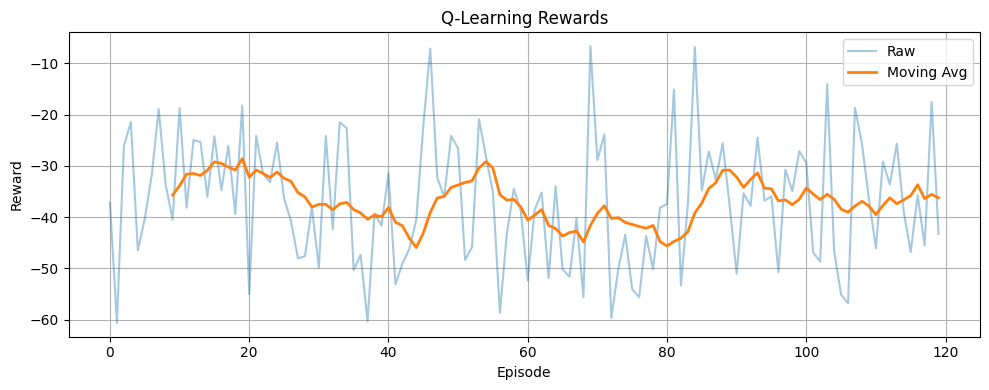

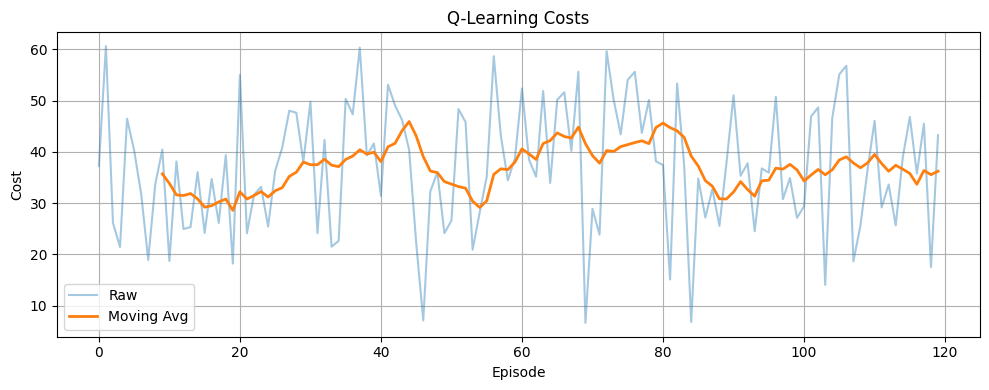

In [80]:
plot_training(q_rewards, "Q-Learning Rewards", "Reward")
plot_training(q_costs, "Q-Learning Costs", "Cost")

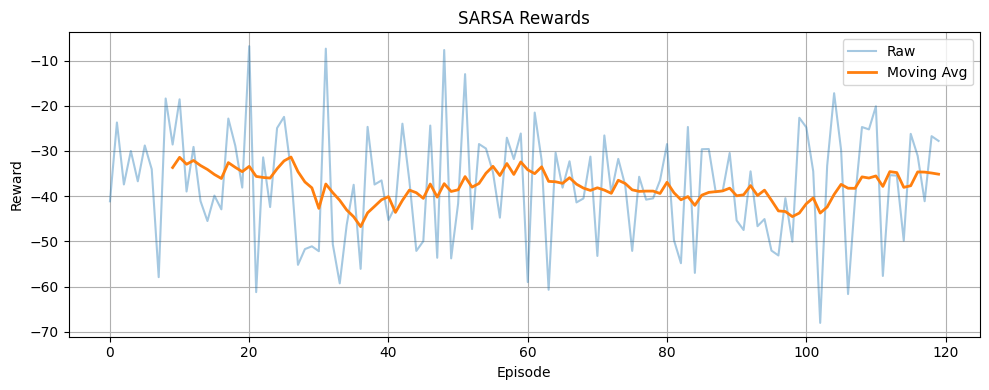

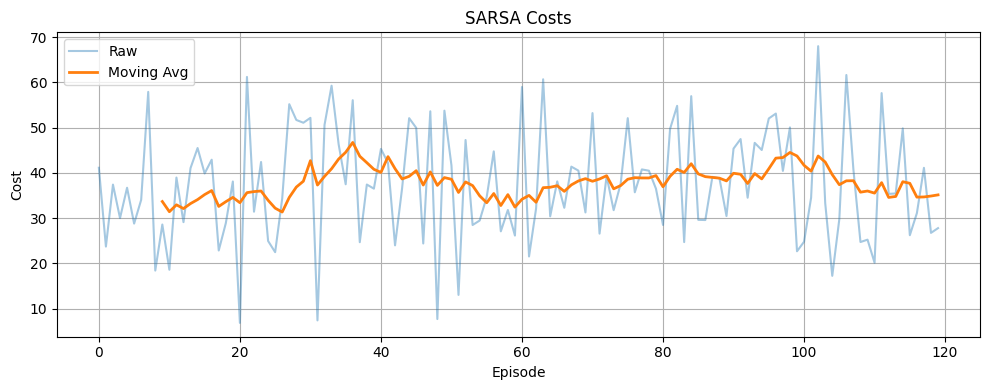

In [81]:
plot_training(s_rewards, "SARSA Rewards", "Reward")
plot_training(s_costs, "SARSA Costs", "Cost")

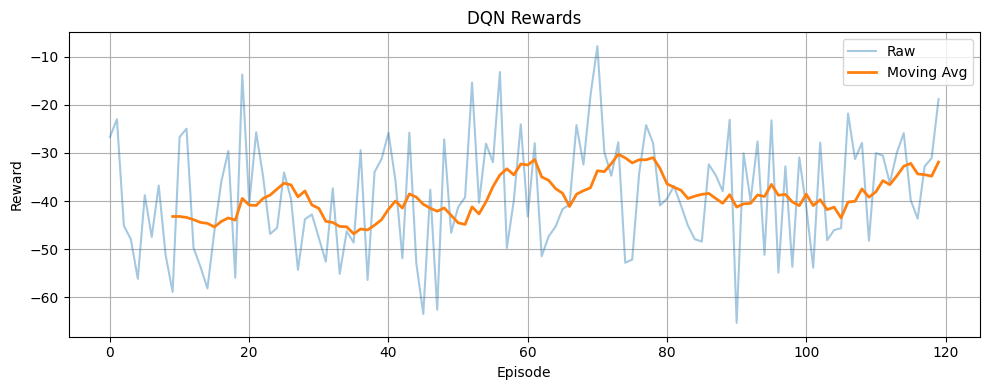

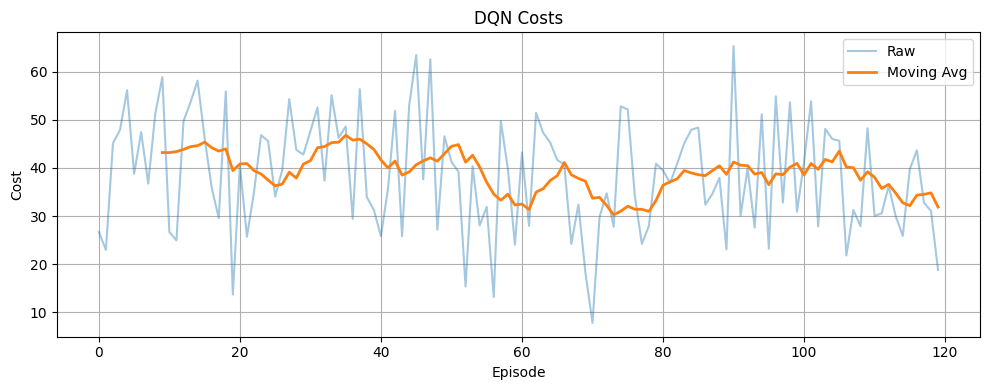

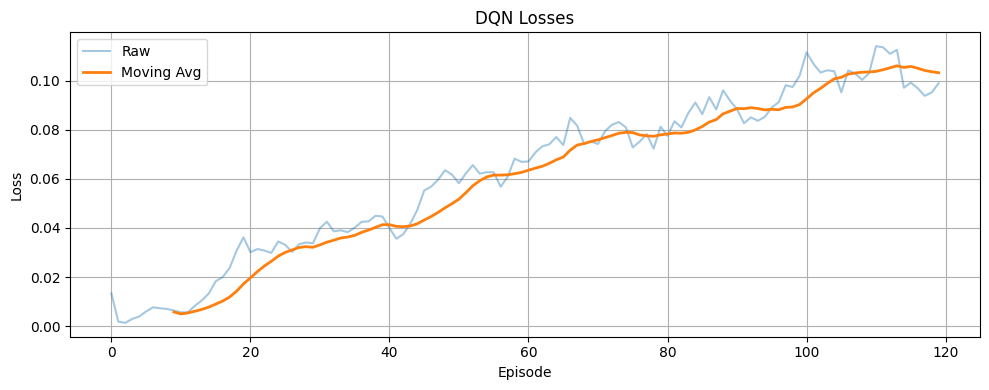

In [82]:
plot_training(d_rewards, "DQN Rewards", "Reward")
plot_training(d_costs, "DQN Costs", "Cost")
plot_training(d_losses, "DQN Losses", "Loss")

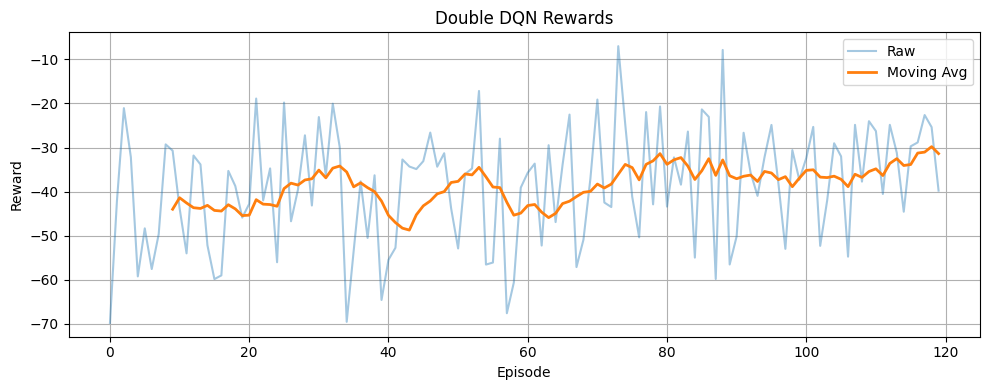

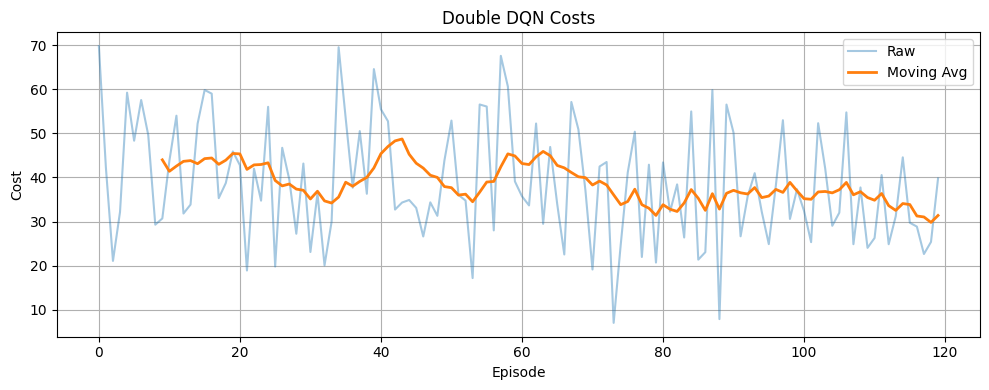

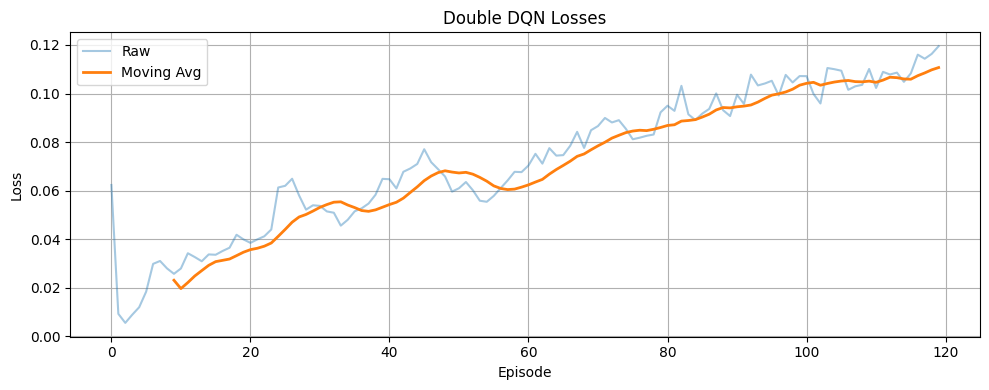

In [83]:
plot_training(dd_rewards, "Double DQN Rewards", "Reward")
plot_training(dd_costs, "Double DQN Costs", "Cost")
plot_training(dd_losses, "Double DQN Losses", "Loss")

### 15. Evaluation

Costs: {'Rule-Based': 22.754890658135587, 'Q-Learning': 29.56762909366199, 'SARSA': 32.36188744596012, 'DQN': 26.984010288135586, 'Double DQN': 22.147670593519038}


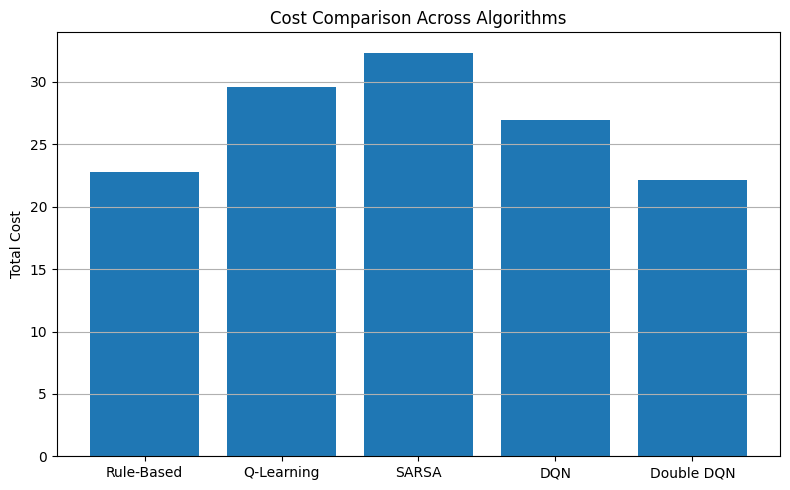

In [84]:
test_start_idx = random.randint(0, len(test_env.df) - EPISODE_LENGTH -1)

rules_result = evaluate_rule_based(test_env, test_start_idx, EPISODE_LENGTH)
q_result = evaluate_tabular(test_env, q_agent, discretizer, test_start_idx, EPISODE_LENGTH)
sarsa_result = evaluate_tabular(test_env, sarsa_agent, discretizer, test_start_idx, EPISODE_LENGTH)
dqn_result = evaluate_dqn(test_env, dqn_agent, state_builder, test_start_idx, EPISODE_LENGTH)
ddqn_result = evaluate_dqn(test_env, ddqn_agent, state_builder, test_start_idx, EPISODE_LENGTH)


all_costs = {
    "Rule-Based": rules_result["total_cost"],
    "Q-Learning": q_result["total_cost"],
    "SARSA": sarsa_result["total_cost"],
    "DQN": dqn_result["total_cost"],
    "Double DQN": ddqn_result["total_cost"],
}

print("Costs:", all_costs)
plot_cost_bar(all_costs)

### 15.1 Detailed Performance Comparison

In [85]:
comparison_data = {
    'Algorithm': [
        'Rule-Based',
        'Q-Learning',
        'SARSA',
        'DQN',
        'Double DQN'
    ],
    'Total Cost': [
        rules_result['total_cost'],
        q_result['total_cost'],
        sarsa_result['total_cost'],
        dqn_result['total_cost'],
        ddqn_result['total_cost']
    ],
    'Total Reward': [
        rules_result['total_reward'],
        q_result['total_reward'],
        sarsa_result['total_reward'],
        dqn_result['total_reward'],
        ddqn_result['total_reward']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.sort_values(by='Total Cost'))

,Algorithm,Total Cost,Total Reward
4,Double DQN,22.147671,-22.147671
0,Rule-Based,22.754891,-22.754891
3,DQN,26.984010,-26.984010
1,Q-Learning,29.567629,-29.567629
2,SARSA,32.361887,-32.361887


### 15.2 Comparative Training Plots

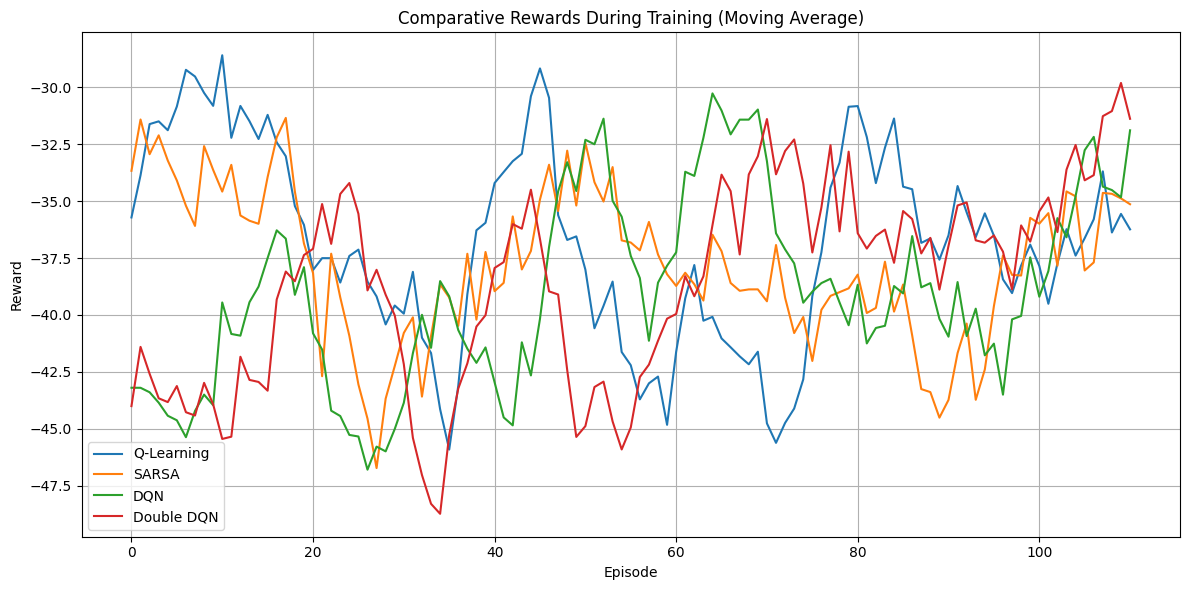

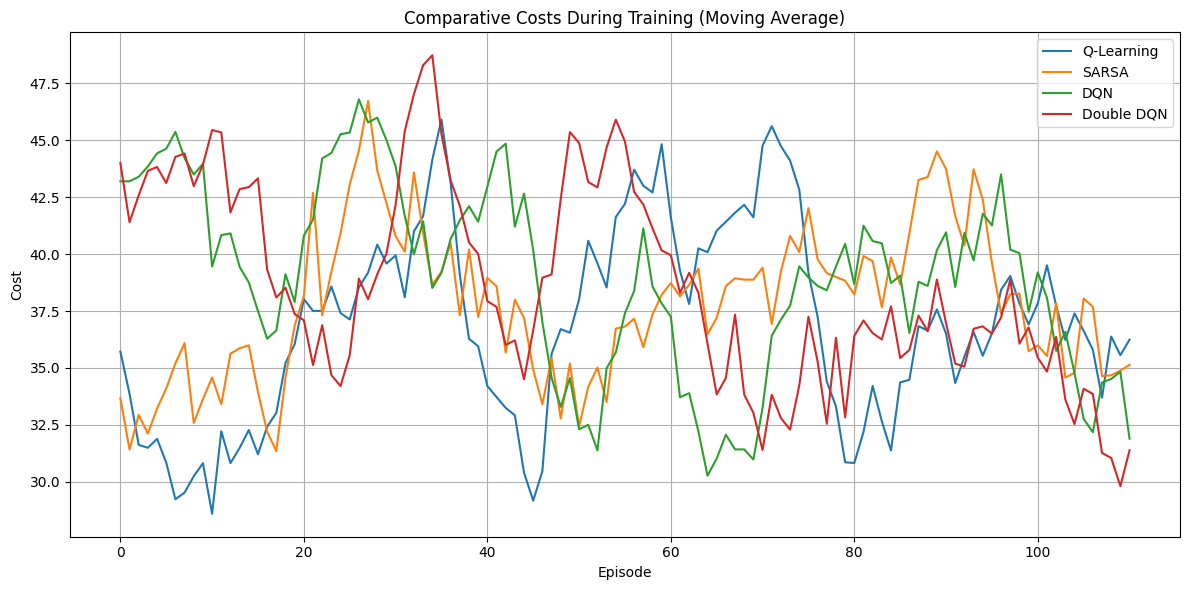

In [86]:
plt.figure(figsize=(12, 6))
plt.plot(moving_average(q_rewards), label='Q-Learning')
plt.plot(moving_average(s_rewards), label='SARSA')
plt.plot(moving_average(d_rewards), label='DQN')
plt.plot(moving_average(dd_rewards), label='Double DQN')
plt.title('Comparative Rewards During Training (Moving Average)')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(moving_average(q_costs), label='Q-Learning')
plt.plot(moving_average(s_costs), label='SARSA')
plt.plot(moving_average(d_costs), label='DQN')
plt.plot(moving_average(dd_costs), label='Double DQN')
plt.title('Comparative Costs During Training (Moving Average)')
plt.xlabel('Episode')
plt.ylabel('Cost')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Based on the "Total Cost" metric, the Rule-Based algorithm yielded the best result with a total cost of 22.75. This is slightly better than the Double DQN algorithm, which came in second with a total cost of 22.94.

Explanation of the Best Result (Rule-Based):
Simplicity and Determinism: The Rule-Based policy is explicitly designed with predefined rules that aim to minimize cost. It leverages known information about peak pricing and battery capacity to make decisions. For instance, it charges during low-price hours (0-6 AM) and discharges during high-price hours (5-10 PM) or when the price is generally high.
Optimized for the Defined Scenario: In this specific simulation environment, where demand and price patterns are somewhat predictable, a well-tuned rule-based system can perform exceptionally well because it directly encodes optimal behavior for those conditions.
No Learning Overhead: Unlike the reinforcement learning agents, the Rule-Based agent does not need to explore or learn. It operates deterministically based on its programmed logic, which can be an advantage if the environment's dynamics are static and fully understood.
Why Double DQN is noteworthy:
Although Rule-Based is slightly better, it's important to note that Double DQN achieved a very close performance. This is significant because:

Learned Policy: Double DQN learned its policy through interaction with the environment, without explicit rules. This demonstrates its ability to discover near-optimal strategies through experience.
Adaptability: Reinforcement Learning agents, especially advanced ones like Double DQN, can adapt to more complex and dynamic environments where explicit rules might be difficult to design or less effective. Their ability to generalize from experience makes them powerful for real-world scenarios that may deviate from perfect predictability.
In essence, while the Rule-Based approach is the "best" in terms of absolute minimum cost in this controlled setting, the Double DQN's near-equivalent performance from a learned policy is a very strong indicator of its potential for more complex and less predictable energy management challenges.



### 16. Battery Level Traces

In [ ]:
### 16. Battery Level Traces

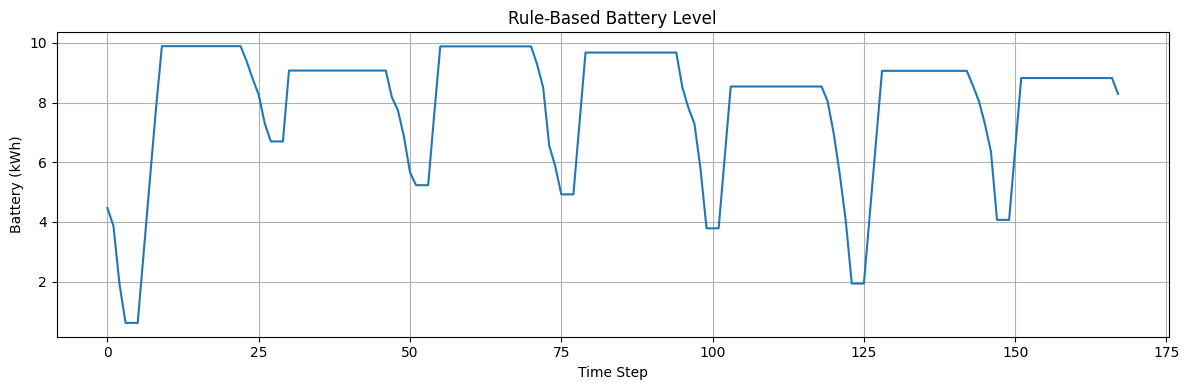

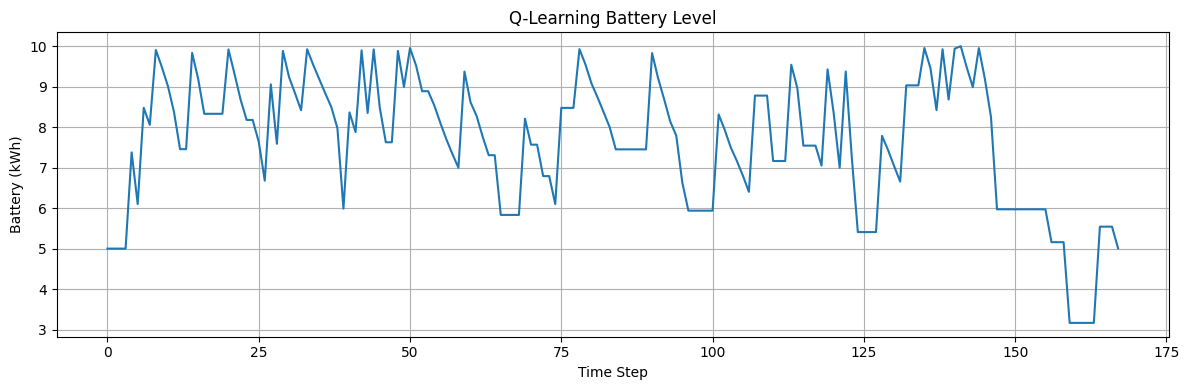

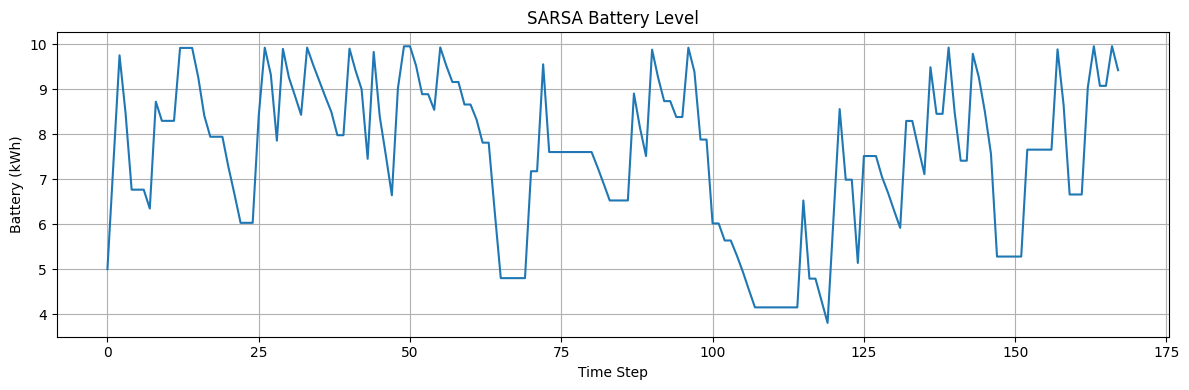

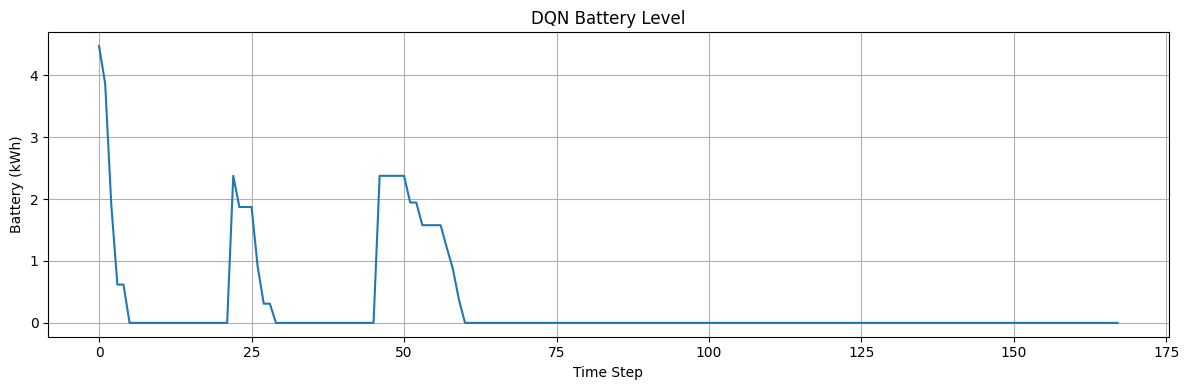

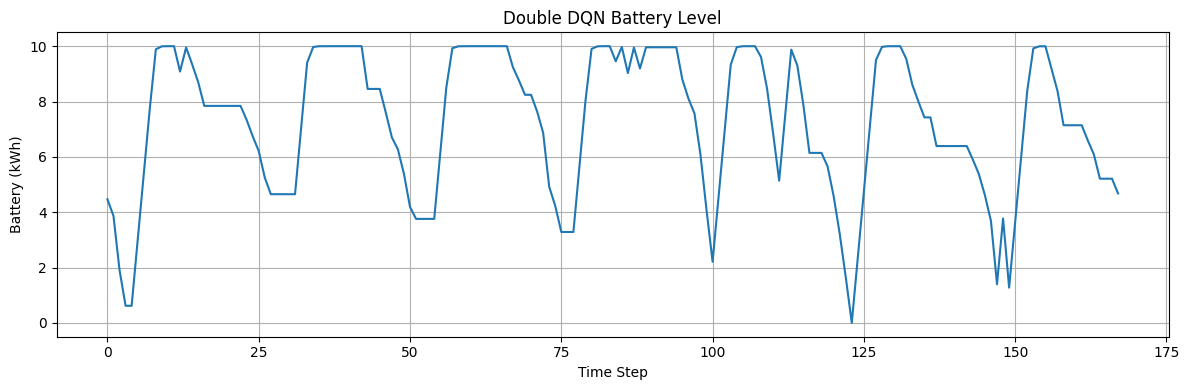

In [95]:
plot_trace(rules_result, "Rule-Based")
plot_trace(q_result, "Q-Learning")
plot_trace(sarsa_result, "SARSA")
plot_trace(dqn_result, "DQN")
plot_trace(ddqn_result, "Double DQN")